In [1]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from torchvision.transforms import v2
from medmnist import PathMNIST

tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])


tf_data_aug = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.5),
    v2.RandomChoice([
        v2.RandomRotation(degrees=(0, 0)),
        v2.RandomRotation(degrees=(90, 90)),
        v2.RandomRotation(degrees=(180, 180)),
        v2.RandomRotation(degrees=(270, 270)),
    ])
])

train_dataset = PathMNIST(root="./data/",split="train",transform=tf_data_aug,download=True,size=64)
val_dataset = PathMNIST(root="./data/",split="val",transform=tf,download=True,size=64)
test_dataset = PathMNIST(root="./data/",split="test",transform=tf,download=True,size=64)

n_labels = len(train_dataset.info["label"].items())

In [3]:
from models.mae import MaskedAutoEncoder,AutoEncoder
from models.cross_predictor_hybrid import Predictor

model_id = "cross_reducer_hybrid"
freeze_encoder = True

mae = MaskedAutoEncoder()
mae.load_state_dict(torch.load("model_weights/v3_pretrain_checkpoints/model_13_epoch_800.pt"))
ae = AutoEncoder(patcher=mae.patcher,encoder=mae.encoder)
model = Predictor(autoencoder=ae,n_labels=n_labels)

if freeze_encoder == True:
    for name, param in model.autoencoder.named_parameters():
        param.requires_grad = False

print(model)


Predictor(
  (autoencoder): AutoEncoder(
    (patcher): CNN(
      (conv): Conv2d(3, 1024, kernel_size=(4, 4), stride=(4, 4))
      (fc): Linear(in_features=1024, out_features=512, bias=True)
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (encoder): Encoder(
      (transformer_blocks): Sequential(
        (0): TransformerBlock(
          (mha): MultiHeadAttention(
            (linear_qkv): Linear(in_features=512, out_features=1536, bias=True)
            (linear_out): Linear(in_features=512, out_features=512, bias=True)
          )
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (ff): FeedForward(
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
            (gelu): GELU(approximate='none')
          )
        )
        (1

In [4]:
from torch.utils.data import DataLoader

num_workers = 4

train_batch_size = 256
val_batch_size = test_batch_size = 256
effective_batch = 256
if 256 % train_batch_size != 0:
    raise ValueError()

train_dl = DataLoader(
    train_dataset,
    batch_size= train_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

val_dl = DataLoader(
    val_dataset,
    batch_size = val_batch_size,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

test_dl = DataLoader(
    test_dataset,
    batch_size= test_batch_size,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)


In [5]:
import math
from torch import nn
from torch import optim

grad_acc = max(1,(256//train_batch_size))
steps_per_epoch = len(train_dl)

epochs = 100
warm_up_epochs = math.ceil(epochs * 0.025)
checkpointing_rate = 10

warm_up_steps = warm_up_epochs*steps_per_epoch
cosine_steps = (epochs - warm_up_epochs)*steps_per_epoch

base_lr = 5e-5
encoder_base_lr = 1e-5
max_lr = base_lr * (effective_batch/256)
encoder_max_lr = encoder_base_lr * (effective_batch/256)
min_lr = 1e-6

if freeze_encoder:
    optimiser = optim.AdamW([
                {"params":model.predictor.parameters(),"lr":max_lr,"betas":(0.9, 0.999),"weight_decay":0.05},
            ])
else:
    optimiser = optim.AdamW([
            {"params":model.autoencoder.parameters(),"lr":encoder_max_lr,"betas":(0.9, 0.999),"weight_decay":0.05},
            {"params":model.predictor.parameters(),"lr":max_lr,"betas":(0.9, 0.999),"weight_decay":0.05},
        ])

loss = nn.CrossEntropyLoss(label_smoothing=0.1)

# start at minimum and go up
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimiser,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warm_up_steps
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimiser,
    T_max=cosine_steps,
    eta_min=min_lr
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimiser,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warm_up_steps]
)


In [6]:
from training_functions import train,test
from tqdm.notebook import tqdm
import time
import csv

log_file_path = f"logs/v3_training_{model_id}_log_{time.time()}.csv"


with open(log_file_path, mode="w", newline="") as f:
    prev_train_loss = None
    prev_val_loss = None
    prev_test_loss = None

    writer = csv.writer(f)
    if freeze_encoder:
        writer.writerow(["epoch", "train_loss", "val_loss","test_loss","train_delta","val_delta","test_delta","predictor_lr","val_acc","test_acc","val_auc","test_auc"])
    else: writer.writerow(["epoch", "train_loss", "val_loss","test_loss","train_delta","val_delta","test_delta","encoder_lr","decoder_lr","val_acc","test_acc","val_auc","test_auc"])

    model = model.to(device)
    torch.set_float32_matmul_precision('high')
    model = torch.compile(model)

    with tqdm(range(epochs),desc="Epochs") as bar:
        for epoch in bar:
            
            train_delta = val_delta = test_delta = 0.0

            train_loss = train(model, device, train_dl, loss, optimiser, epoch, scheduler, grad_acc)

            if freeze_encoder:
                current_predictor_lr = optimiser.param_groups[0]['lr']
            else:
                current_encoder_lr = optimiser.param_groups[0]['lr']
                current_predictor_lr = optimiser.param_groups[1]['lr']

            val_loss,val_acc,val_auc = test(model, device, val_dl, loss,epoch)
            test_loss,test_acc,test_auc = test(model,device,test_dl,loss,epoch,test_type="Testing")

            train_delta = train_loss - prev_train_loss  if prev_train_loss is not None else 0.0
            val_delta = val_loss - prev_val_loss if prev_val_loss is not None else 0.0
            test_delta = test_loss - prev_test_loss if prev_test_loss is not None else 0.0

            prev_train_loss = train_loss
            prev_val_loss = val_loss
            prev_test_loss = test_loss

            if freeze_encoder:
                bar.set_postfix({
                    "train_loss": f"{train_loss:.4f}",
                    "val_loss": f"{val_loss:.4f}",
                    "test_loss": f"{test_loss:.4f}",
                    "train_delta":f"{train_delta:+.3e}",
                    "val_delta":f"{val_delta:+.3e}",
                    "test_delta":f"{test_delta:+.3e}",
                    "lr": f"{current_predictor_lr:.3e}",
                    "val_accuracy":f"{val_acc:.4f}",
                    "test_accuracy":f"{test_acc:.4f}",
                    "val_auc":f"{val_auc:.4f}",
                    "test_auc":f"{test_auc:.4f}"
                })
            else:
                bar.set_postfix({
                        "train_loss": f"{train_loss:.4f}",
                        "val_loss": f"{val_loss:.4f}",
                        "test_loss": f"{test_loss:.4f}",
                        "train_delta":f"{train_delta:+.3e}",
                        "val_delta":f"{val_delta:+.3e}",
                        "test_delta":f"{test_delta:+.3e}",
                        "encoder_lr": f"{current_encoder_lr:.3e}",
                        "predictor_lr": f"{current_predictor_lr:.3e}",
                        "val_accuracy":f"{val_acc:.4f}",
                        "test_accuracy":f"{test_acc:.4f}",
                        "val_auc":f"{val_auc:.4f}",
                        "test_auc":f"{test_auc:.4f}"
                    })
            if freeze_encoder:
                writer.writerow([epoch+1,train_loss,val_loss,test_loss,train_delta,val_delta,test_delta,current_predictor_lr,val_acc,test_acc,val_auc,test_auc])
            else:
                writer.writerow([epoch+1,train_loss,val_loss,test_loss,train_delta,val_delta,test_delta,current_encoder_lr,current_predictor_lr,val_acc,test_acc,val_auc,test_auc])
            f.flush()

            if (epoch+1) % checkpointing_rate == 0:
                torch.save(model._orig_mod.state_dict() if hasattr(model, '_orig_mod') else model.state_dict(),f"model_weights/v3_checkpoints/model_{model_id}_epoch_{epoch+1}.pt")

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: Training:   0%|          | 0/352 [00:00<?, ?it/s]

W0815 03:18:44.728000 7896 torch/_inductor/utils.py:1953] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1: Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1: Testing:   0%|          | 0/29 [00:00<?, ?it/s]

...

Epoch 99: Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 99: Testing:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 100: Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 100: Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 100: Testing:   0%|          | 0/29 [00:00<?, ?it/s]

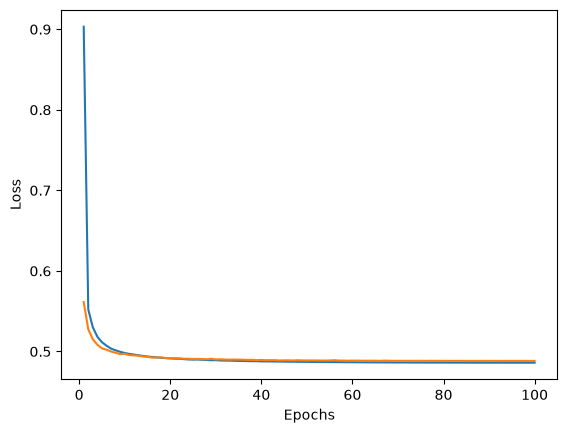

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import time

dataframe = pd.read_csv(log_file_path)

plt.plot(dataframe["epoch"],dataframe["train_loss"])
plt.plot(dataframe["epoch"],dataframe["val_loss"])
plt.title
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.savefig(f"graphs/training/train_v3_loss_{model_id}_{time.time()}.png")
plt.show()
plt.close()